Electron Hit Acceptance Analysis

Parameters:
  e = 0.3
  B = 0.8333
  L = 1.2
  z = 0.934

Acceptance window: 0.06766 ≤ y_front ≤ 0.25326

Valid P range: 1.8380 to 6.8055
Number of accepted points: 2762


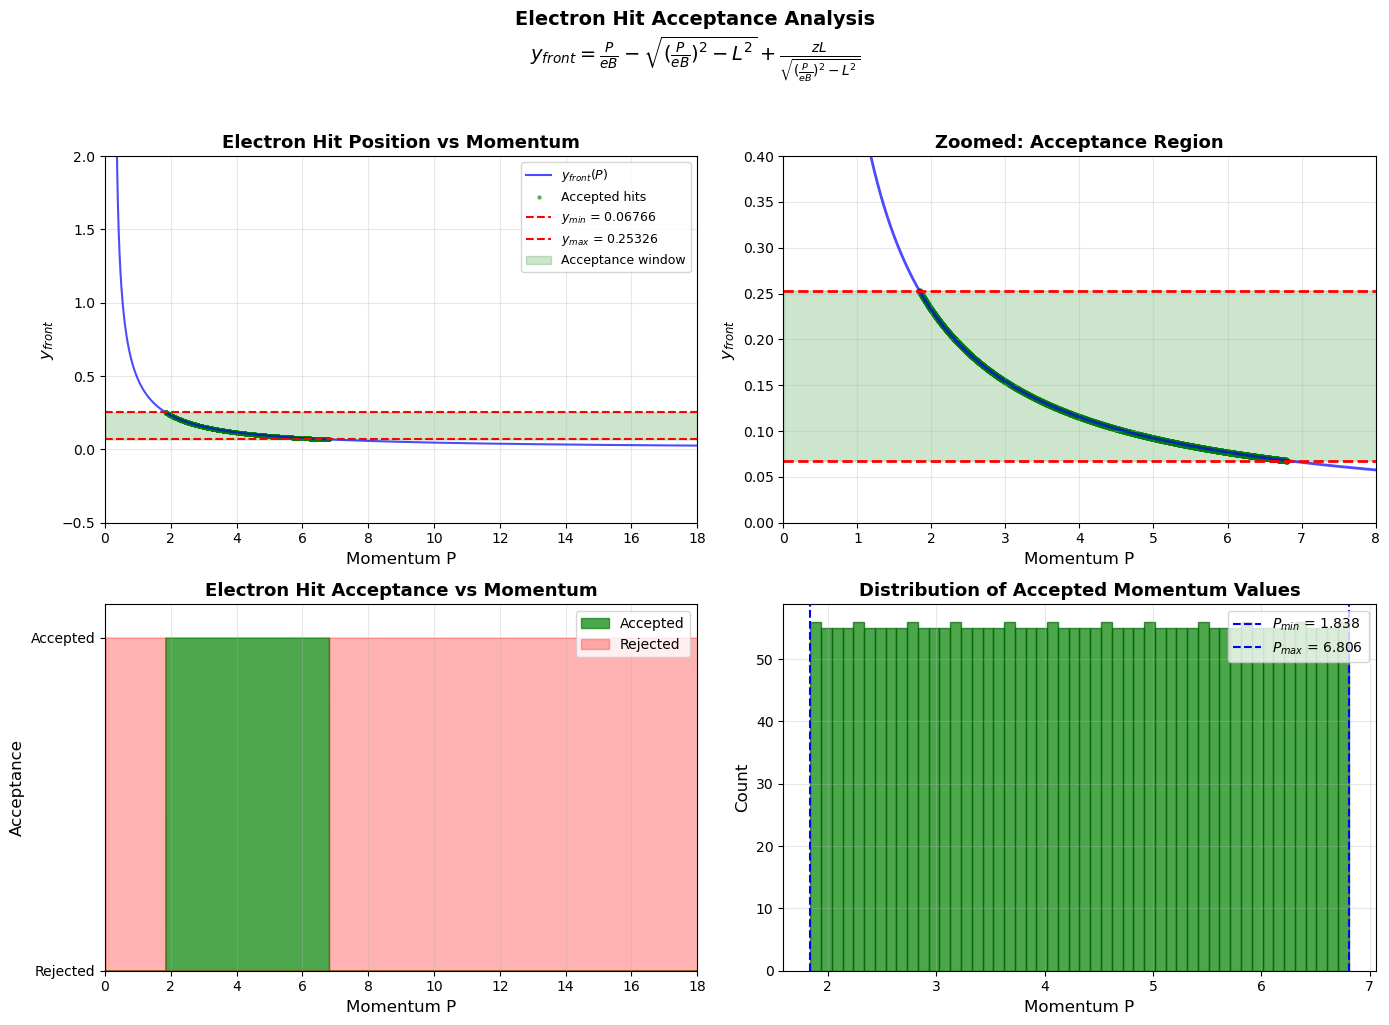


Plot saved: electron_acceptance.png


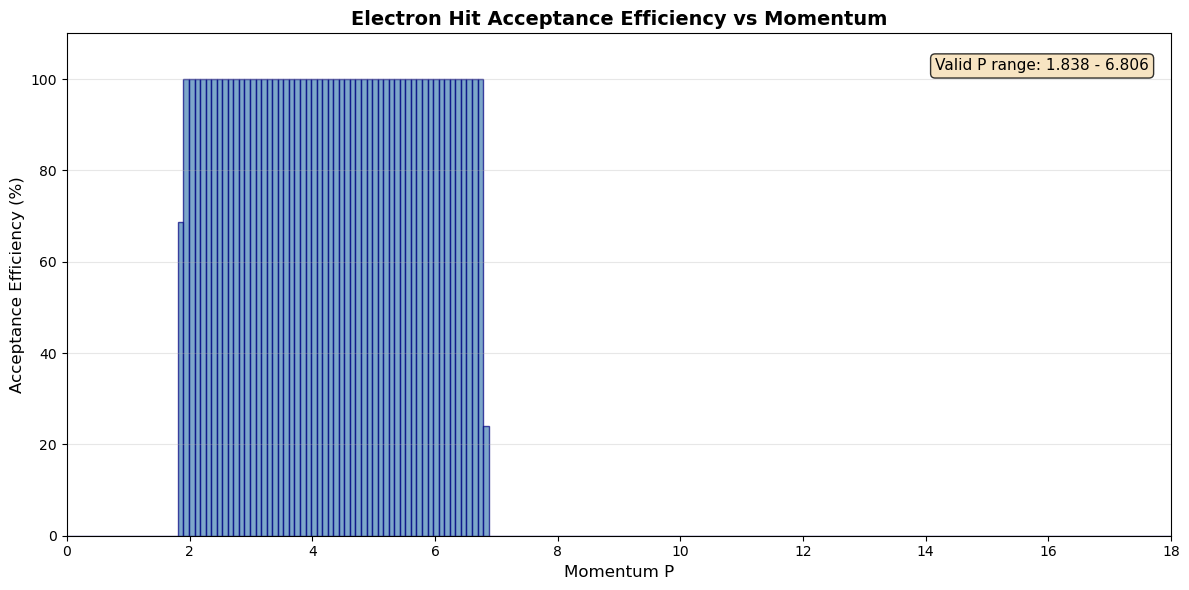

Plot saved: electron_acceptance_efficiency.png

Valid P Values Summary
First 10 values: [1.8379668  1.83976598 1.84156516 1.84336434 1.84516352 1.8469627
 1.84876188 1.85056106 1.85236024 1.85415942]
Last 10 values: [6.78930993 6.79110911 6.79290829 6.79470747 6.79650665 6.79830583
 6.80010501 6.80190419 6.80370337 6.80550255]

Total accepted P values: 2762


In [1]:
"""
Electron Hit Acceptance Analysis
Based on MATLAB code for calculating valid P ranges for electron detection
"""

import numpy as np
import matplotlib.pyplot as plt

# Define parameters from the MATLAB code
e = 0.3          # efficiency/eccentricity parameter
B = 1/1.2        # magnetic field parameter
L = 1.2          # length parameter
z = 0.934        # position parameter

# Define the range for P (momentum)
P_values = np.linspace(0.01, 18, 10000)  # Avoid P=0 to prevent division issues

# Calculate yfront values
# yfront = (P / (e * B)) - sqrt((P / (e * B))^2 - L^2) + (z * L) / sqrt((P / (e * B))^2 - L^2)
term1 = P_values / (e * B)
# Only calculate where the sqrt argument is positive
valid_sqrt = term1**2 - L**2
valid_sqrt = np.where(valid_sqrt > 0, valid_sqrt, np.nan)

sqrt_term = np.sqrt(valid_sqrt)
yfront_values = term1 - sqrt_term + (z * L) / sqrt_term

# Define acceptance bounds
y_min = 0.06766
y_max = 0.25326

# Filter yfront values based on the acceptance condition
valid_indices = (yfront_values >= y_min) & (yfront_values <= y_max)
valid_P = P_values[valid_indices]
valid_yfront = yfront_values[valid_indices]

# Print statistics
print("="*60)
print("Electron Hit Acceptance Analysis")
print("="*60)
print(f"\nParameters:")
print(f"  e = {e}")
print(f"  B = {B:.4f}")
print(f"  L = {L}")
print(f"  z = {z}")
print(f"\nAcceptance window: {y_min} ≤ y_front ≤ {y_max}")
print(f"\nValid P range: {valid_P.min():.4f} to {valid_P.max():.4f}")
print(f"Number of accepted points: {len(valid_P)}")

# ============================================================
# PLOT 1: yfront vs P with acceptance region
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top Left: Full curve with acceptance region highlighted
ax1 = axes[0, 0]
ax1.plot(P_values, yfront_values, 'b-', linewidth=1.5, label='$y_{front}(P)$', alpha=0.7)
ax1.scatter(valid_P, valid_yfront, c='green', s=5, alpha=0.5, label='Accepted hits')
ax1.axhline(y=y_min, color='red', linestyle='--', linewidth=1.5, label=f'$y_{{min}}$ = {y_min}')
ax1.axhline(y=y_max, color='red', linestyle='--', linewidth=1.5, label=f'$y_{{max}}$ = {y_max}')
ax1.fill_between(P_values, y_min, y_max, alpha=0.2, color='green', label='Acceptance window')
ax1.set_xlabel('Momentum P', fontsize=12)
ax1.set_ylabel('$y_{front}$', fontsize=12)
ax1.set_title('Electron Hit Position vs Momentum', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 18)
ax1.set_ylim(-0.5, 2)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Top Right: Zoomed view of acceptance region
ax2 = axes[0, 1]
ax2.plot(P_values, yfront_values, 'b-', linewidth=2, alpha=0.7)
ax2.scatter(valid_P, valid_yfront, c='green', s=10, alpha=0.6, label='Accepted hits')
ax2.axhline(y=y_min, color='red', linestyle='--', linewidth=2)
ax2.axhline(y=y_max, color='red', linestyle='--', linewidth=2)
ax2.fill_between(P_values, y_min, y_max, alpha=0.2, color='green')
ax2.set_xlabel('Momentum P', fontsize=12)
ax2.set_ylabel('$y_{front}$', fontsize=12)
ax2.set_title('Zoomed: Acceptance Region', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 8)
ax2.set_ylim(0, 0.4)
ax2.grid(True, alpha=0.3)

# Bottom Left: Acceptance as binary (1 = accepted, 0 = rejected)
ax3 = axes[1, 0]
acceptance = np.where(valid_indices, 1, 0)
ax3.fill_between(P_values, 0, acceptance, color='green', alpha=0.7, label='Accepted')
ax3.fill_between(P_values, 0, 1-acceptance, color='red', alpha=0.3, label='Rejected')
ax3.set_xlabel('Momentum P', fontsize=12)
ax3.set_ylabel('Acceptance', fontsize=12)
ax3.set_title('Electron Hit Acceptance vs Momentum', fontsize=13, fontweight='bold')
ax3.set_xlim(0, 18)
ax3.set_ylim(0, 1.1)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Rejected', 'Accepted'])
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3, axis='x')

# Bottom Right: Histogram of accepted P values
ax4 = axes[1, 1]
ax4.hist(valid_P, bins=50, color='green', edgecolor='darkgreen', alpha=0.7)
ax4.set_xlabel('Momentum P', fontsize=12)
ax4.set_ylabel('Count', fontsize=12)
ax4.set_title('Distribution of Accepted Momentum Values', fontsize=13, fontweight='bold')
ax4.axvline(x=valid_P.min(), color='blue', linestyle='--', label=f'$P_{{min}}$ = {valid_P.min():.3f}')
ax4.axvline(x=valid_P.max(), color='blue', linestyle='--', label=f'$P_{{max}}$ = {valid_P.max():.3f}')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('Electron Hit Acceptance Analysis\n$y_{front} = \\frac{P}{eB} - \\sqrt{(\\frac{P}{eB})^2 - L^2} + \\frac{zL}{\\sqrt{(\\frac{P}{eB})^2 - L^2}}$', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('electron_acceptance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved: electron_acceptance.png")

# ============================================================
# PLOT 2: Acceptance efficiency curve
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate running acceptance efficiency
window_size = 100
P_bins = np.linspace(0, 18, 200)
acceptance_efficiency = []

for i in range(len(P_bins)-1):
    mask = (P_values >= P_bins[i]) & (P_values < P_bins[i+1])
    total = np.sum(mask)
    accepted = np.sum(mask & valid_indices)
    if total > 0:
        acceptance_efficiency.append(accepted / total * 100)
    else:
        acceptance_efficiency.append(0)

P_centers = (P_bins[:-1] + P_bins[1:]) / 2

ax.bar(P_centers, acceptance_efficiency, width=P_bins[1]-P_bins[0], 
       color='steelblue', edgecolor='navy', alpha=0.7)
ax.set_xlabel('Momentum P', fontsize=12)
ax.set_ylabel('Acceptance Efficiency (%)', fontsize=12)
ax.set_title('Electron Hit Acceptance Efficiency vs Momentum', fontsize=14, fontweight='bold')
ax.set_xlim(0, 18)
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis='y')

# Add text annotation
textstr = f'Valid P range: {valid_P.min():.3f} - {valid_P.max():.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.98, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('electron_acceptance_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved: electron_acceptance_efficiency.png")

# ============================================================
# Print valid P values summary (matching MATLAB output)
# ============================================================
print("\n" + "="*60)
print("Valid P Values Summary")
print("="*60)
print(f"First 10 values: {valid_P[:10]}")
print(f"Last 10 values: {valid_P[-10:]}")
print(f"\nTotal accepted P values: {len(valid_P)}")